# Comparaison Baseline vs Finetune — Prompt 3

Compare les scores (**macro F1**) et les erreurs entre le modèle baseline et le modèle finetuné, **globalement** et par type d'énoncé (**POL** vs **MEDICAL**). La colonne « reasoning » des CSV n’est pas utilisée ici.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import f1_score

def macro_f1(y_true, y_pred):
    """Macro F1 entre les labels Entailment et Contradiction."""
    return f1_score(y_true, y_pred, labels=["Contradiction", "Entailment"], average="macro")

GRAPHS_DIR = "graphes"
os.makedirs(GRAPHS_DIR, exist_ok=True)

df_base = pd.read_csv("eval_cot_combined_baseline.csv")
df_fine = pd.read_csv("eval_cot_combined_finetune.csv")

df = df_base[["index", "statement_type", "gold"]].copy()
df["pred_baseline"] = df_base["prediction"]
df["pred_finetune"] = df_fine["prediction"]
df["correct_baseline"] = df_base["is_correct"]
df["correct_finetune"] = df_fine["is_correct"]

print("Lignes chargées:", len(df))
df.head()

Lignes chargées: 3156


,index,statement_type,gold,pred_baseline,pred_finetune,correct_baseline,correct_finetune
0,0,pol,Entailment,Entailment,Entailment,True,True
1,1,pol,Contradiction,Entailment,Entailment,False,False
2,2,pol,Entailment,Entailment,Entailment,True,True
3,3,pol,Contradiction,Contradiction,Contradiction,True,True
4,4,pol,Contradiction,Contradiction,Contradiction,True,True


Macro F1 (0–1) :


,Baseline,Finetune,Δ
statement_type,,,
pol,0.705640,0.723441,0.0178
medical,0.739233,0.732999,-0.0062
Global,0.722610,0.728235,0.0056


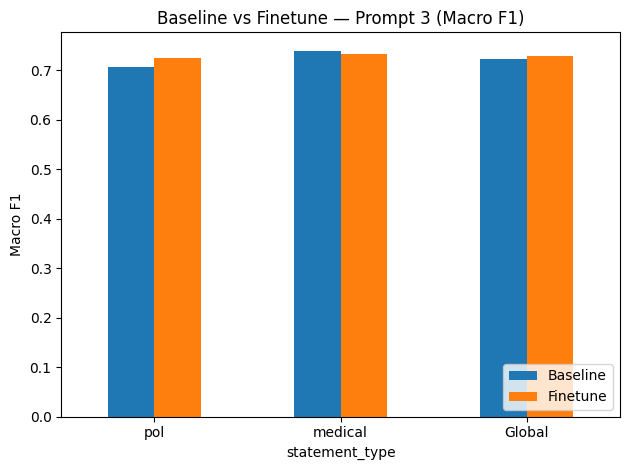

In [2]:
# Scores : macro F1 globale et par statement_type
rows = []
for stype in ["pol", "medical"]:
    sub = df[df["statement_type"] == stype]
    b, f = macro_f1(sub["gold"], sub["pred_baseline"]), macro_f1(sub["gold"], sub["pred_finetune"])
    rows.append((stype, b, f))
rows.append(("Global", macro_f1(df["gold"], df["pred_baseline"]), macro_f1(df["gold"], df["pred_finetune"])))
scores = pd.DataFrame(rows, columns=["statement_type", "Baseline", "Finetune"]).set_index("statement_type")
scores["Δ"] = (scores["Finetune"] - scores["Baseline"]).round(4)
print("Macro F1 (0–1) :")
display(scores)
scores[["Baseline", "Finetune"]].plot(kind="bar", ylabel="Macro F1", title="Baseline vs Finetune — Prompt 3 (Macro F1)", rot=0);
plt.legend(loc="lower right");
plt.tight_layout();
plt.savefig(os.path.join(GRAPHS_DIR, "prompt3_compare_baseline_finetune_macro_f1.png"), dpi=150, bbox_inches="tight");
plt.show();

Répartition des accords / désaccords :


,Les deux corrects,"Baseline faux, Finetune OK","Baseline OK, Finetune faux",Les deux faux
Global,1813,516,467,360
POL,879,279,233,187
MEDICAL,934,237,234,173


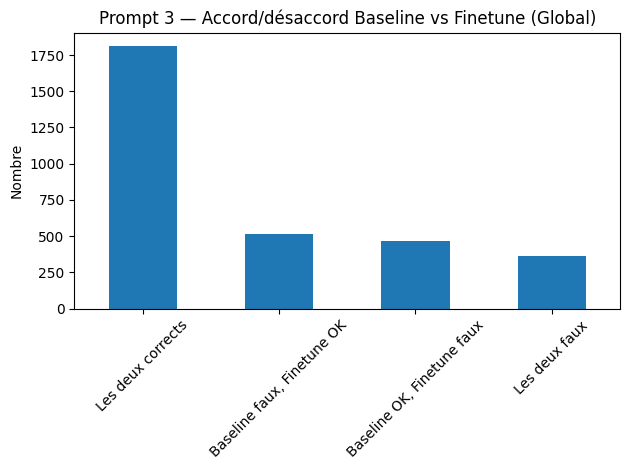

In [3]:
df["both_ok"]    = df["correct_baseline"] & df["correct_finetune"]
df["base_wrong"] = ~df["correct_baseline"] & df["correct_finetune"]
df["fine_wrong"] = df["correct_baseline"] & ~df["correct_finetune"]
df["both_wrong"] = ~df["correct_baseline"] & ~df["correct_finetune"]

counts = pd.DataFrame({
    "Les deux corrects": [df["both_ok"].sum(), df[df["statement_type"]=="pol"]["both_ok"].sum(), df[df["statement_type"]=="medical"]["both_ok"].sum()],
    "Baseline faux, Finetune OK": [df["base_wrong"].sum(), df[df["statement_type"]=="pol"]["base_wrong"].sum(), df[df["statement_type"]=="medical"]["base_wrong"].sum()],
    "Baseline OK, Finetune faux": [df["fine_wrong"].sum(), df[df["statement_type"]=="pol"]["fine_wrong"].sum(), df[df["statement_type"]=="medical"]["fine_wrong"].sum()],
    "Les deux faux": [df["both_wrong"].sum(), df[df["statement_type"]=="pol"]["both_wrong"].sum(), df[df["statement_type"]=="medical"]["both_wrong"].sum()],
}, index=["Global", "POL", "MEDICAL"])
print("Répartition des accords / désaccords :")
display(counts)
counts_global = counts.loc["Global"]
counts_global.plot(kind="bar", ylabel="Nombre", title="Prompt 3 — Accord/désaccord Baseline vs Finetune (Global)", rot=45);
plt.tight_layout();
plt.savefig(os.path.join(GRAPHS_DIR, "prompt3_compare_baseline_finetune_accord_desaccord.png"), dpi=150, bbox_inches="tight");
plt.show();

In [4]:
err_base = ~df["correct_baseline"]
err_fine = ~df["correct_finetune"]
fixed = err_base & df["correct_finetune"]
new_err = df["correct_baseline"] & err_fine

overlap = pd.DataFrame({
    "Erreurs baseline": [err_base.sum(), err_base[df["statement_type"]=="pol"].sum(), err_base[df["statement_type"]=="medical"].sum()],
    "% corrigées par finetune": [
        (fixed.sum() / err_base.sum() * 100) if err_base.sum() else 0,
        (fixed[df["statement_type"]=="pol"].sum() / err_base[df["statement_type"]=="pol"].sum() * 100) if err_base[df["statement_type"]=="pol"].sum() else 0,
        (fixed[df["statement_type"]=="medical"].sum() / err_base[df["statement_type"]=="medical"].sum() * 100) if err_base[df["statement_type"]=="medical"].sum() else 0,
    ],
    "Nouvelles erreurs finetune": [new_err.sum(), new_err[df["statement_type"]=="pol"].sum(), new_err[df["statement_type"]=="medical"].sum()],
}, index=["Global", "POL", "MEDICAL"])
print("Synthèse erreurs :")
display(overlap.round(2))

Synthèse erreurs :


,Erreurs baseline,% corrigées par finetune,Nouvelles erreurs finetune
Global,876,58.90,467
POL,466,59.87,233
MEDICAL,410,57.80,234
